In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('/Users/liukebing/Desktop/Data Analysis/Data/Brazilian E-commerce Dataset by Olist/olist_cluster_review.csv')

In [5]:
df_cluster2=df[df['cluster']==2]

In [6]:
df_cluster2.head()

,customer_unique_id,order_id,cluster,full_review
13,97f0fce3f9d7aad1b12499a4e4b10d07,4d483bf690ca21bdc005df9b623673c7,2,. boa
14,172e5ceb39fc662dc3cd66286385e91c,32638fbca8d1a197e649fd5138e12049,2,. Ocorreu tudo como contratado sendo a entreg...
22,4c5ae17e8984ca0916543b159eac0f2c,d5ba80d74b52c335ae36398d6159e6ee,2,". Chegou apenas uma peça, mas na nota e na ga..."
23,f98ba45b711901694978daec941423c3,e18ebd6286697a3f0f6fe267d8286cb2,2,. EU NÃO RECEBI O PRODUTO E CONSTA NO SISTEMA...
29,4badbcac33ce2de21e8cd1eb1f5d0770,1e91914c9706a5d4665b8c5a6294b107,2,4 . Se fosse vidro tinha quebrado; veio na ...


In [7]:
!pip install deep-translator

In [8]:
from deep_translator import GoogleTranslator

In [9]:
def translate_to_english(text):
    if not text or not isinstance(text, str):
        return text
    try:
        return GoogleTranslator(source='pt', target='en').translate(text)
    except:
        return text

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [11]:
portuguese_stopwords = ['de', 'do', 'da', 'que', 'um', 'uma', 'com', 'foi', 'para', 'na', 'no']
tfidf = TfidfVectorizer(max_features=10, stop_words=portuguese_stopwords) 
tfidf_matrix = tfidf.fit_transform(df_cluster2['full_review'])

In [12]:
word_freq = pd.DataFrame(tfidf_matrix.sum(axis=0).T, 
                         index=tfidf.get_feature_names_out(), 
                         columns=['freq'])

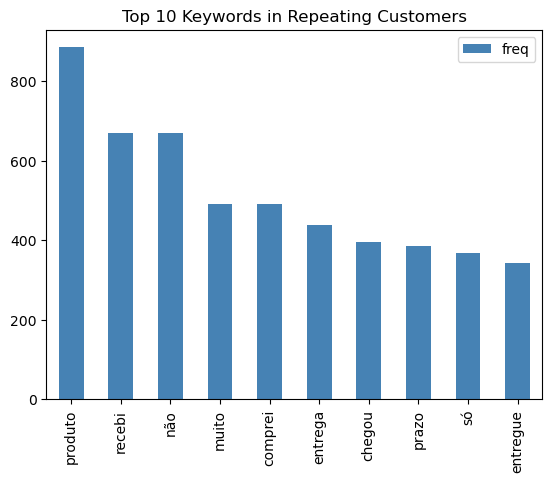

In [13]:
word_freq.sort_values(by='freq', ascending=False).plot(kind='bar', color='steelblue')
plt.title("Top 10 Keywords in Repeating Customers")
plt.show()

In [14]:
df_cluster3=df[df['cluster']==3]

In [16]:
portuguese_stopwords = ['de', 'do', 'da', 'que', 'um', 'uma', 'com', 'foi', 'para', 'na', 'no']
tfidf3 = TfidfVectorizer(max_features=10, stop_words=portuguese_stopwords) 
tfidf_matrix3 = tfidf3.fit_transform(df_cluster3['full_review'])

In [17]:
word_freq3 = pd.DataFrame(tfidf_matrix3.sum(axis=0).T, 
                         index=tfidf3.get_feature_names_out(), 
                         columns=['freq'])

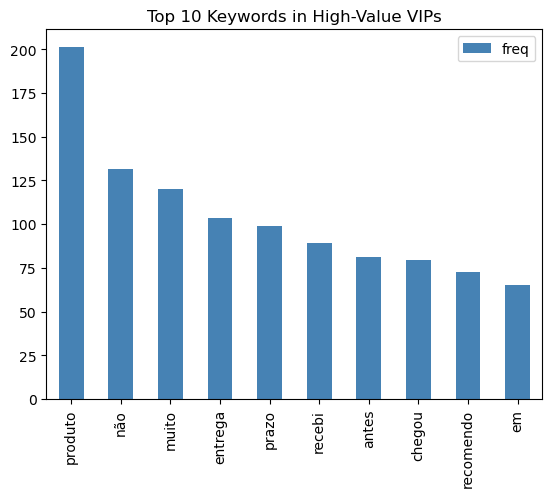

In [18]:
word_freq3.sort_values(by='freq', ascending=False).plot(kind='bar', color='steelblue')
plt.title("Top 10 Keywords in High-Value VIPs")
plt.show()